<a href="https://colab.research.google.com/github/amit-sahu-a11y/ML_projects_for_practice/blob/main/model_training4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Simple ML Model Training Example

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### 1. Load the Dataset

We'll use the famous Iris dataset, which is a classic dataset for classification tasks. It contains measurements of sepal length, sepal width, petal length, and petal width for three species of iris flowers.

In [2]:
# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target (y) head:


,0
0,0
1,0
2,0
3,0
4,0


### 2. Split Data into Training and Testing Sets

It's crucial to split your data into training and testing sets. The model learns from the training data, and its performance is evaluated on unseen test data to ensure it generalizes well.

In [3]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 105 samples
Testing set size: 45 samples


### 3. Train a Machine Learning Model

We'll use Logistic Regression, a simple yet effective classification algorithm, to train our model on the training data.

In [4]:
# Initialize and train a Logistic Regression model
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### 4. Evaluate the Model

After training, we evaluate the model's performance on the test data. Accuracy score is a common metric for classification tasks, indicating the proportion of correctly predicted instances.

In [5]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.4f}")

Model Accuracy on Test Set: 0.9333


### 5. Visualize Model Performance with a Confusion Matrix

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows for the visualization of the performance of an algorithm. We can use it to identify patterns of misclassification.

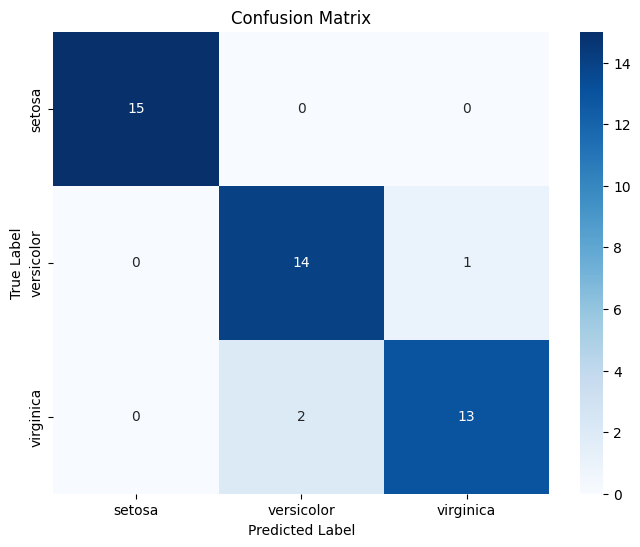

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### 6. Calculate Precision and Recall

**Precision** is the ratio of correctly predicted positive observations to the total predicted positive observations. High precision relates to a low false positive rate.

**Recall** (also known as Sensitivity) is the ratio of correctly predicted positive observations to all observations in actual class. High recall relates to a low false negative rate.

Since this is a multi-class classification problem, we will use the `average='weighted'` parameter to account for label imbalance.

In [7]:
from sklearn.metrics import precision_score, recall_score

# Calculate precision and recall
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f"Precision Score (weighted): {precision:.4f}")
print(f"Recall Score (weighted): {recall:.4f}")

Precision Score (weighted): 0.9345
Recall Score (weighted): 0.9333


### 7. Visualize Feature Importance

For a Logistic Regression model, the absolute values of the coefficients can be interpreted as feature importance. A larger absolute coefficient value indicates a more significant impact of that feature on the model's prediction.

/tmp/ipykernel_431/3923545887.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


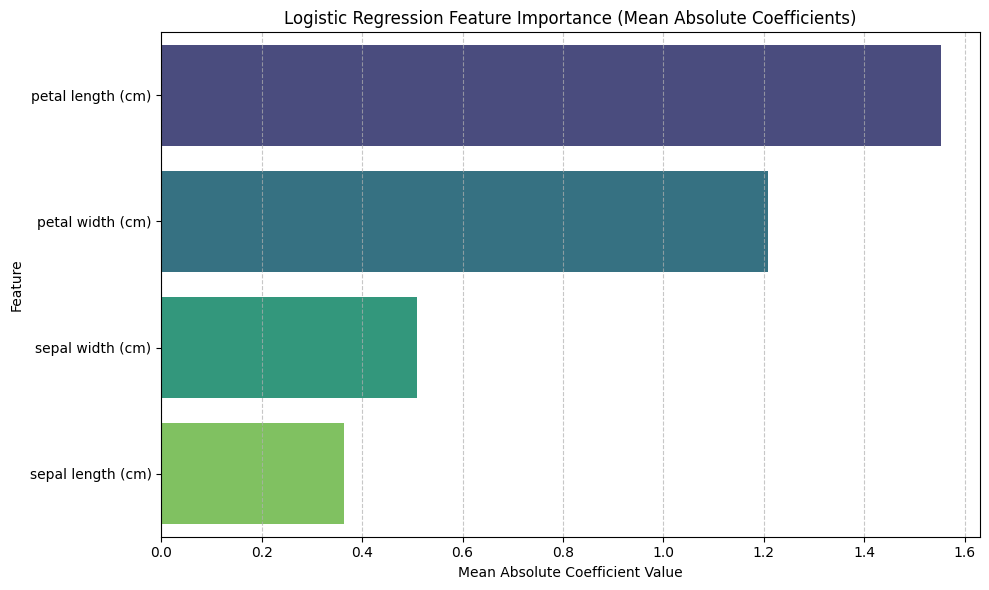

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names
feature_names = iris.feature_names

# Get coefficients from the trained model
# For multi-class, LogisticRegression provides one coefficient array per class.
# We'll take the mean of the absolute coefficients across classes for an overall importance.
coefficients = model.coef_

# Calculate the mean of absolute coefficients as a measure of importance
feature_importance = np.mean(np.abs(coefficients), axis=0)

# Create a DataFrame for easier plotting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Logistic Regression Feature Importance (Mean Absolute Coefficients)')
plt.xlabel('Mean Absolute Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()